## 1. Library Imports

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 2. CSV File Imports

In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
defensive_stats_original = pd.read_csv('/content/drive/MyDrive/Defensive Stats - whoscored - Sheet1.csv')
miscellaneous_stats_original = pd.read_csv('/content/drive/MyDrive/Miscellaneous Stats - fbref - Sheet1.csv')
offensive_stats_original = pd.read_csv('/content/drive/MyDrive/Offensive Stats - whoscored - Sheet1.csv')
passing_stats_original = pd.read_csv('/content/drive/MyDrive/Passing Stats - whoscored - Sheet1.csv')
shooting_stats_original = pd.read_csv('/content/drive/MyDrive/Shooting Stats - fbref - Sheet1.csv')

## 3. Cleaning Datasets

### 3.1 Shooting Stats Dataset

In [88]:
shooting_stats = shooting_stats_original.copy()
shooting_stats.head(3)

,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt
0,James Abankwah,ie IRL,RB,Watford,22-038,2004.0,18.3,0,6,0,0.0,0.33,0.00,0.00,NaN,0,0
1,Ebou Adams,gm GAM,MF,Derby County,30-039,1996.0,16.7,1,9,1,11.1,0.54,0.06,0.11,1.0,0,0
2,Ebou Adams,gm GAM,MF,Portsmouth,30-039,1996.0,7.3,2,14,5,35.7,1.92,0.68,0.14,0.4,0,0


In [89]:
shooting_stats = shooting_stats.drop(["Nation", "Born", "Sh", "SoT", "SoT%" , "G/Sh", "G/SoT", "PK", "PKatt" ] , axis = 1)

In [90]:
duplicates_before = shooting_stats["Player"].duplicated(keep = False).sum()
print("Number of duplicate player names before removal:", duplicates_before)

Number of duplicate player names before removal: 82


In [91]:
shooting_stats = shooting_stats[~shooting_stats["Player"].duplicated(keep = False)]

In [92]:
# Check to ensure no duplicate players remain after filtering
duplicates_after = shooting_stats["Player"].duplicated(keep = False).sum()
print("Number of duplicate player names after removal:", duplicates_after)

Number of duplicate player names after removal: 0


In [93]:
shooting_stats["Age"] = shooting_stats["Age"].str.split('-').str[0]

In [94]:
# @title
shooting_stats.head(3)

,Player,Pos,Squad,Age,90s,Gls,Sh/90,SoT/90
0,James Abankwah,RB,Watford,22,18.3,0,0.33,0.00
3,Kealey Adamson,RB,Queens Park Rangers,22,0.6,0,6.92,0.00
4,Tayo Adaramola,LB,Sheffield Weds,22,2.7,0,0.73,0.37


In [95]:
shooting_stats = shooting_stats.dropna(subset = ["Age"])

In [96]:
shooting_stats["Age"].isnull().sum()

np.int64(0)

In [97]:
shooting_stats["Age"] = shooting_stats["Age"].astype(str).astype(int)

In [98]:
shooting_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 0 to 763
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  668 non-null    object 
 1   Pos     668 non-null    object 
 2   Squad   668 non-null    object 
 3   Age     668 non-null    int64  
 4   90s     668 non-null    float64
 5   Gls     668 non-null    int64  
 6   Sh/90   668 non-null    float64
 7   SoT/90  668 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 47.0+ KB


### 3.2 Offensive Stats Dataset

In [99]:
offensive_stats = offensive_stats_original.copy()

In [100]:
offensive_stats = offensive_stats.drop(["Apps", "Mins", "Goals", "Assists", "SpG" , "KeyP", "Disp", "UnsTch", "Rating" ] , axis = 1)

In [101]:
offensive_stats = offensive_stats.replace("-", "0")

In [102]:
offensive_stats.head(3)

,Player,Drb,Fouled,Off
0,Mohamed Touré,1.3,0.7,1.3
1,Divine Mukasa,0.3,0,0
2,Eiran Cashin,0.3,0,0


In [103]:
offensive_stats["Drb"] = offensive_stats["Drb"].astype(str).astype(float)
offensive_stats["Fouled"] = offensive_stats["Fouled"].astype(str).astype(float)
offensive_stats["Off"] = offensive_stats["Off"].astype(str).astype(float)

In [104]:
offensive_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  764 non-null    object 
 1   Drb     764 non-null    float64
 2   Fouled  764 non-null    float64
 3   Off     764 non-null    float64
dtypes: float64(3), object(1)
memory usage: 24.0+ KB


In [105]:
offensive_stats = offensive_stats[~offensive_stats["Player"].duplicated(keep = False)]

### 3.3 Defensive Stats Dataset

In [106]:
defensive_stats = defensive_stats_original.copy()
defensive_stats_original.head(3)

,Player,Apps,Mins,Tackles,Inter,Fouls,Offsides,Clear,Drb,Blocks,OwnG,Rating
0,Mohamed Touré,2(1),170,-,0.3,0.3,-,0.3,-,-,-,7.78
1,Divine Mukasa,2(1),167,1.3,-,1.3,-,0.3,0.3,-,-,7.67
2,Eiran Cashin,7,630,4.6,1.9,1.4,-,6.1,1.1,1,1,7.58


In [107]:
defensive_stats = defensive_stats.drop(["Apps", "Mins", "Offsides", "OwnG", "Drb", "Rating" ] , axis = 1)

In [108]:
defensive_stats = defensive_stats.replace("-", "0")

In [109]:
defensive_stats["Tackles"] = defensive_stats["Tackles"].astype(str).astype(float)
defensive_stats["Inter"] = defensive_stats["Inter"].astype(str).astype(float)
defensive_stats["Fouls"] = defensive_stats["Fouls"].astype(str).astype(float)
defensive_stats["Clear"] = defensive_stats["Clear"].astype(str).astype(float)
defensive_stats["Blocks"] = defensive_stats["Blocks"].astype(str).astype(float)

In [110]:
defensive_stats = defensive_stats[~defensive_stats["Player"].duplicated(keep = False)]

In [111]:
defensive_stats.head(3)

,Player,Tackles,Inter,Fouls,Clear,Blocks
0,Mohamed Touré,0.0,0.3,0.3,0.3,0.0
1,Divine Mukasa,1.3,0.0,1.3,0.3,0.0
3,Jonathan Panzo,2.0,2.0,1.0,14.0,1.0


### 3.4 Miscellaneous Stats Dataset

In [112]:
miscellaneous_stats = miscellaneous_stats_original.copy()

In [113]:
shooting_stats = shooting_stats.dropna(subset = ["Age"])

In [114]:
miscellaneous_stats = miscellaneous_stats.drop(["Nation", "Pos", "Born", "Squad", "Age", "Born", "CrdY", "CrdR", "2CrdY", "Fls", "Fld", "Off", "Crs", "Int", "PKwon", "PKcon", "OG"] , axis = 1)

In [115]:
miscellaneous_stats = miscellaneous_stats[~miscellaneous_stats["Player"].duplicated(keep = False)]

In [116]:
miscellaneous_stats["TklW/90"] = (miscellaneous_stats["TklW"] / miscellaneous_stats["90s"]).round(1)

In [117]:
miscellaneous_stats = miscellaneous_stats.drop(["90s", "TklW"] , axis = 1)

In [118]:
miscellaneous_stats.head(3)

,Player,TklW/90
0,James Abankwah,1.1
3,Kealey Adamson,1.7
4,Tayo Adaramola,2.6


### 3.5 Passing Stats Dataset

In [119]:
passing_stats = passing_stats_original.copy()

In [120]:
passing_stats = passing_stats.drop(["Apps", "Mins", "PS%", "Rating"] , axis = 1)

In [121]:
passing_stats = passing_stats.replace("-", "0")

In [122]:
passing_stats.head(2)

,Player,Assists,KeyP,AvgP,Crosses,LongB,ThrB
0,Mohamed Touré,1,0.7,8.3,0,0,0
1,Divine Mukasa,2,3.3,29.7,0.7,1.3,0


In [123]:
passing_stats["Assists"] = passing_stats["Assists"].astype(str).astype(int)
passing_stats["KeyP"] = passing_stats["KeyP"].astype(str).astype(float)
passing_stats["AvgP"] = passing_stats["AvgP"].astype(str).astype(float)
passing_stats["Crosses"] = passing_stats["Crosses"].astype(str).astype(float)
passing_stats["LongB"] = passing_stats["LongB"].astype(str).astype(float)
passing_stats["ThrB"] = passing_stats["ThrB"].astype(str).astype(float)

In [124]:
passing_stats = passing_stats[~passing_stats["Player"].duplicated(keep = False)]

In [125]:
passing_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 682 entries, 0 to 762
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   682 non-null    object 
 1   Assists  682 non-null    int64  
 2   KeyP     682 non-null    float64
 3   AvgP     682 non-null    float64
 4   Crosses  682 non-null    float64
 5   LongB    682 non-null    float64
 6   ThrB     682 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 42.6+ KB


## 4. Combined Final Dataset

In [126]:
championship_player_stats = pd.merge(shooting_stats, offensive_stats, on = "Player", how = "inner")
championship_player_stats = pd.merge(championship_player_stats, defensive_stats, on = "Player", how = "inner")
championship_player_stats = pd.merge(championship_player_stats, miscellaneous_stats, on = "Player", how = "inner")
championship_player_stats = pd.merge(championship_player_stats, passing_stats, on = "Player", how = "inner")

In [127]:
championship_player_stats.head(2)

,Player,Pos,Squad,Age,90s,Gls,Sh/90,SoT/90,Drb,Fouled,...,Fouls,Clear,Blocks,TklW/90,Assists,KeyP,AvgP,Crosses,LongB,ThrB
0,James Abankwah,RB,Watford,22,18.3,0,0.33,0.0,0.5,0.8,...,1.2,5.8,0.4,1.1,0,0.4,41.0,0.1,1.7,0.0
1,Kealey Adamson,RB,Queens Park Rangers,22,0.6,0,6.92,0.0,0.3,0.3,...,0.7,0.3,0.0,1.7,0,0.3,6.3,0.0,0.3,0.0


In [128]:
championship_player_stats.columns = ["Player", "Position", "Club", "Age", "90s", "Goals", "Sh", "SoT", "Drb", "FlsW", "Off", "Tkl", "Int", "Fls", "Clr", "Blk", "TklW", "Assists", "KeyP", "AvgP", "Crs", "LongB", "ThrB"]

In [129]:
championship_player_stats.columns

Index(['Player', 'Position', 'Club', 'Age', '90s', 'Goals', 'Sh', 'SoT', 'Drb',
       'FlsW', 'Off', 'Tkl', 'Int', 'Fls', 'Clr', 'Blk', 'TklW', 'Assists',
       'KeyP', 'AvgP', 'Crs', 'LongB', 'ThrB'],
      dtype='object')

In [130]:
championship_player_stats.shape

(579, 23)

In [131]:
championship_player_stats.head(2)

,Player,Position,Club,Age,90s,Goals,Sh,SoT,Drb,FlsW,...,Fls,Clr,Blk,TklW,Assists,KeyP,AvgP,Crs,LongB,ThrB
0,James Abankwah,RB,Watford,22,18.3,0,0.33,0.0,0.5,0.8,...,1.2,5.8,0.4,1.1,0,0.4,41.0,0.1,1.7,0.0
1,Kealey Adamson,RB,Queens Park Rangers,22,0.6,0,6.92,0.0,0.3,0.3,...,0.7,0.3,0.0,1.7,0,0.3,6.3,0.0,0.3,0.0


## 5. Data Cleaning for PCA


In [132]:
championship_player_stats.describe()

,Age,90s,Goals,Sh,SoT,Drb,FlsW,Off,Tkl,Int,Fls,Clr,Blk,TklW,Assists,KeyP,AvgP,Crs,LongB,ThrB
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,569.0,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,25.848014,11.960967,1.378238,1.304214,0.393420,0.331261,0.581002,0.093782,0.893782,0.485320,0.637306,1.771503,0.210190,inf,0.925734,0.498100,22.824180,0.231088,1.309672,0.018135
std,4.325955,9.653339,2.335289,2.089875,1.024742,0.367833,0.511174,0.163956,0.681208,0.457436,0.471643,2.028235,0.314774,NaN,1.462215,0.472034,14.795411,0.386181,1.662712,0.049208
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.500000,3.250000,0.000000,0.285000,0.000000,0.000000,0.200000,0.000000,0.350000,0.100000,0.300000,0.400000,0.000000,0.4,0.000000,0.100000,11.400000,0.000000,0.200000,0.000000
50%,25.000000,9.600000,0.000000,0.860000,0.200000,0.200000,0.500000,0.000000,0.800000,0.400000,0.600000,1.000000,0.100000,0.9,0.000000,0.400000,20.600000,0.100000,0.700000,0.000000
75%,29.000000,20.050000,2.000000,1.815000,0.575000,0.500000,0.800000,0.100000,1.300000,0.800000,0.900000,2.300000,0.300000,1.3,1.000000,0.800000,32.100000,0.300000,1.650000,0.000000
max,40.000000,33.000000,13.000000,22.500000,22.500000,2.300000,4.000000,1.100000,3.600000,2.000000,4.000000,14.000000,3.000000,inf,9.000000,3.300000,70.100000,3.000000,9.800000,0.400000


In [133]:
df_cleaned = championship_player_stats[championship_player_stats["90s"] >= 10.8].copy()

In [134]:
pca_data1 = df_cleaned.copy()
pca_data = pca_data1.drop(['Player', 'Position', 'Club', 'Age', '90s'], axis = 1)
pca_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 574
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Goals    268 non-null    int64  
 1   Sh       268 non-null    float64
 2   SoT      268 non-null    float64
 3   Drb      268 non-null    float64
 4   FlsW     268 non-null    float64
 5   Off      268 non-null    float64
 6   Tkl      268 non-null    float64
 7   Int      268 non-null    float64
 8   Fls      268 non-null    float64
 9   Clr      268 non-null    float64
 10  Blk      268 non-null    float64
 11  TklW     268 non-null    float64
 12  Assists  268 non-null    int64  
 13  KeyP     268 non-null    float64
 14  AvgP     268 non-null    float64
 15  Crs      268 non-null    float64
 16  LongB    268 non-null    float64
 17  ThrB     268 non-null    float64
dtypes: float64(16), int64(2)
memory usage: 39.8 KB


In [135]:
pca_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 574
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Goals    268 non-null    int64  
 1   Sh       268 non-null    float64
 2   SoT      268 non-null    float64
 3   Drb      268 non-null    float64
 4   FlsW     268 non-null    float64
 5   Off      268 non-null    float64
 6   Tkl      268 non-null    float64
 7   Int      268 non-null    float64
 8   Fls      268 non-null    float64
 9   Clr      268 non-null    float64
 10  Blk      268 non-null    float64
 11  TklW     268 non-null    float64
 12  Assists  268 non-null    int64  
 13  KeyP     268 non-null    float64
 14  AvgP     268 non-null    float64
 15  Crs      268 non-null    float64
 16  LongB    268 non-null    float64
 17  ThrB     268 non-null    float64
dtypes: float64(16), int64(2)
memory usage: 39.8 KB


## 6. Scaling

In [136]:
scaler = StandardScaler(with_mean = True, with_std = True)
pca_data_scaled = scaler.fit_transform(pca_data)
print("Scaled Data Mean (should be ~0):", pca_data_scaled.mean(axis = 0))
print("Scaled Data Std Dev (should be ~1):", pca_data_scaled.std(axis = 0))

Scaled Data Mean (should be ~0): [ 1.98845915e-17  1.19307549e-16 -6.62819716e-18  9.44518096e-17
  4.97114787e-17 -6.62819716e-18  2.38615098e-16 -1.12679352e-16
 -1.32563943e-17 -1.52448535e-16 -9.61088588e-17  2.60156739e-16
  6.62819716e-18  1.12679352e-16 -2.01331489e-16  1.98845915e-17
 -4.80544294e-17  4.97114787e-17]
Scaled Data Std Dev (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Correlation heatmap

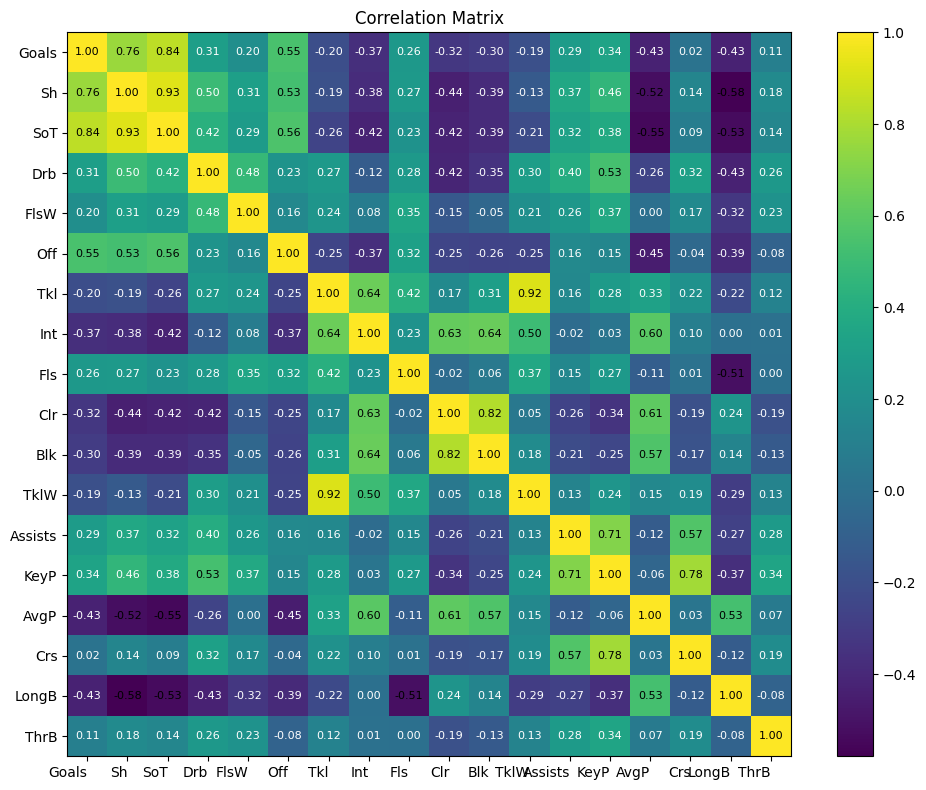

In [137]:
corr = pca_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="viridis")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if abs(corr.iloc[i, j]) < 0.5 else "black",
            fontsize=8
        )

plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()


plt.savefig("hitmap.png", dpi=300, bbox_inches='tight')
plt.show()

##8. PCA

In [138]:
pca= PCA()
pca.fit(pca_data_scaled)
scores= pca.transform(pca_data_scaled)
scores.shape

(268, 18)

## 9. Scree Plot

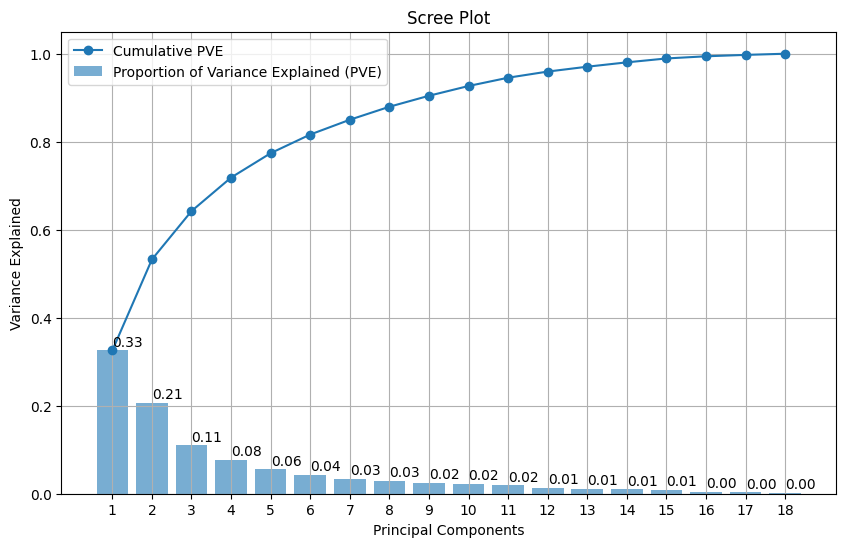

In [139]:
pve = pca.explained_variance_ratio_
cumulative_pve = np.cumsum(pve)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pve) + 1),
        pve, alpha=0.6, label="Proportion of Variance Explained (PVE)")

for i, v in enumerate(pve):
    plt.text(i+1, v+0.01, f'{v:.2f}')



plt.plot(range(1, len(pve) + 1), cumulative_pve, marker="o", label="Cumulative PVE")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.xticks(range(1, len(pve)+1))
plt.legend()
plt.grid()
plt.savefig("scree plot.png", dpi=300, bbox_inches='tight')
plt.show()

## 10. Loading Heatmap

In [140]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=pca_data.columns
)



loadings_3 = loadings.iloc[:, :3]

In [141]:
attack = ["Goals","Sh","SoT","Drb","Off"]
defense = ["Tkl","TklW", "Int","Clr","Blk","Fls"]
play = ["Assists","KeyP","ThrB", "Crs"]
style = ["AvgP","LongB"]

ordered = attack + defense + play + style

loadings_3= loadings_3.loc[ordered]

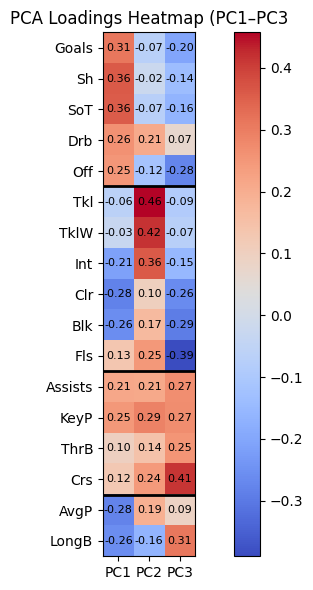

In [142]:
plt.figure(figsize=(8,6))
plt.imshow(loadings_3, cmap="coolwarm")

plt.xticks(range(loadings_3.shape[1]), loadings_3.columns)
plt.yticks(range(loadings_3.shape[0]), loadings_3.index)

for i in range(loadings_3.shape[0]):
    for j in range(loadings_3.shape[1]):
        plt.text(j, i, f"{loadings_3.iloc[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.colorbar()
plt.title("PCA Loadings Heatmap (PC1–PC3")
plt.tight_layout()
plt.axhline(4.5, color="black", linewidth=2)
plt.axhline(10.5, color="black", linewidth=2)
plt.axhline(14.5, color="black", linewidth=2)
plt.savefig("pca loadings heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


## 11. Biplots: PC1 vs PC2 & PC1 vs PC3

In [143]:
loadings_3

,PC1,PC2,PC3
Goals,0.310603,-0.067740,-0.202764
Sh,0.361175,-0.021993,-0.137335
SoT,0.355969,-0.071608,-0.164373
Drb,0.261096,0.208456,0.070231
Off,0.249600,-0.115300,-0.276282
Tkl,-0.062179,0.457292,-0.087465
TklW,-0.031873,0.416542,-0.070247
Int,-0.211801,0.358449,-0.154005
Clr,-0.283215,0.102296,-0.263378
Blk,-0.257577,0.167166,-0.291438


In [144]:
loadings_3.head()
biplot_loading1 = loadings_3.copy()

biplot_loading1 = loadings_3.drop(['Sh', 'SoT', 'Off',
                                     'TklW', 'Clr','Blk','Fls',
                                     'ThrB','Crs',], axis = 0)
biplot_loading1

,PC1,PC2,PC3
Goals,0.310603,-0.067740,-0.202764
Drb,0.261096,0.208456,0.070231
Tkl,-0.062179,0.457292,-0.087465
Int,-0.211801,0.358449,-0.154005
Assists,0.214457,0.209197,0.265579
KeyP,0.247179,0.289219,0.269408
AvgP,-0.277183,0.192790,0.089600
LongB,-0.259528,-0.162023,0.309546


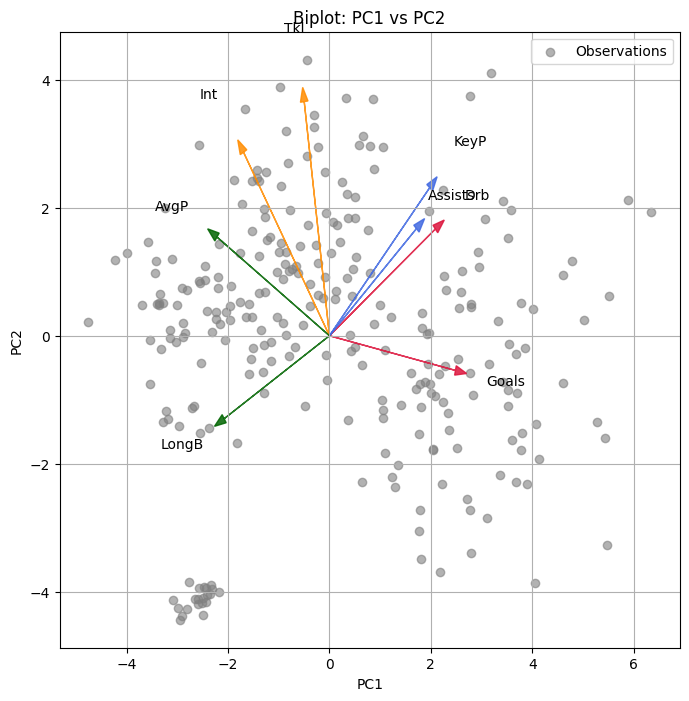

In [145]:
i, j = 0, 1
fig, ax = plt.subplots(1, 1, figsize=(8, 8))


ax.scatter(scores[:, i], scores[:, j], alpha=0.6, label='Observations', c='gray')

colors = ['crimson', 'crimson', 'darkorange', 'darkorange',
          'royalblue', 'royalblue', 'darkgreen', 'darkgreen']
for idx, a in enumerate(biplot_loading1.index):
    x= biplot_loading1.loc[a, f'PC{i+1}']
    y = biplot_loading1.loc[a, f'PC{j+1}']
    ax.arrow(0, 0, x * 8, y * 8,
             color=colors[idx], alpha=0.85, head_width=0.15)
    ax.text(x * 8 * 1.4, y * 7.5* 1.4,
            a, color='black', fontsize=10, ha='center', va='center')

ax.set_xlabel(f'PC{i+1}')
ax.set_ylabel(f'PC{j+1}')
ax.set_title('Biplot: PC1 vs PC2')
ax.grid()
ax.legend()
plt.savefig("biplot1", dpi=300, bbox_inches='tight')
plt.show()

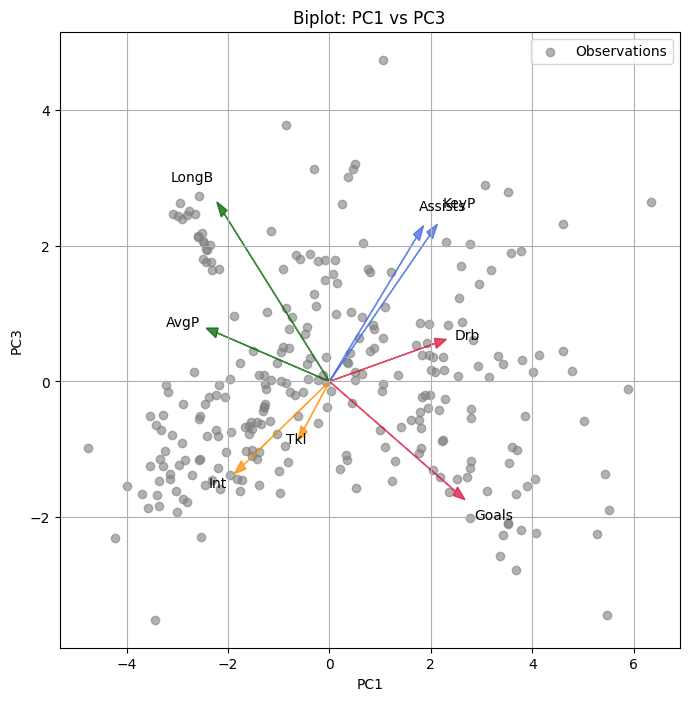

In [146]:
o = 2

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:, i], scores[:, o], alpha=0.6, label= 'Observations', c = 'gray')


for idx, a in enumerate(biplot_loading1.index):
    x= biplot_loading1.loc[a, f'PC{i+1}']
    z = biplot_loading1.loc[a, f'PC{o+1}']
    ax.arrow(0, 0, x * 8, z * 8,
             color=colors[idx], alpha=0.75, head_width=0.15)
    ax.text(x * 8 * 1.3, z * 7.5 * 1.3,
            a, color='black', fontsize=10, ha='center', va='center')

ax.set_xlabel(f'PC{i+1}')
ax.set_ylabel(f'PC{o+1}')
ax.set_title('Biplot: PC1 vs PC3')
ax.grid()
ax.legend()
plt.savefig("biplot1", dpi=300, bbox_inches='tight')
plt.show()

## 12. Business Application 1 - Player Recruiting

In [147]:
loadings = pd.DataFrame(pca.components_.T, columns=[f" PC {i + 1}" for i in range(pca.n_components_)], index = pca_data.columns)

In [148]:
pca = PCA()

pca_scores = pca.fit_transform(pca_data_scaled)

loadings = pd.DataFrame(pca.components_.T, columns=[f" PC {i + 1}" for i in range(pca.n_components_)], index = pca_data.columns)

scores_df = pd.DataFrame(pca_scores, columns = [f"PC{i + 1}" for i in range(pca.n_components_)])

scores_df.head(2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,-2.189448,0.914894,-1.270596,-0.437696,0.037372,0.761762,0.413230,-0.009259,0.352542,-0.421973,0.643191,-0.290254,0.329075,-0.019292,0.845955,0.242181,0.077417,0.153918
1,5.274348,-1.340641,-2.256563,0.908334,0.379049,1.953047,0.887374,0.385823,-0.002306,0.289852,0.663404,-0.293969,0.765267,-0.053340,-0.057471,-0.162558,-0.225372,-0.041674


In [149]:
scores_df["Player"] = df_cleaned["Player"].values
scores_df["Club"] = df_cleaned["Club"].values
scores_df["Position"] = df_cleaned["Position"].values
scores_df["Age"] = df_cleaned["Age"].values

scores_df_reduced = scores_df[["Player", "Club", "Position", "Age", "PC1", "PC2", "PC3"]]

scores_df_reduced.head()

,Player,Club,Position,Age,PC1,PC2,PC3
0,James Abankwah,Watford,RB,22,-2.189448,0.914894,-1.270596
1,Patrick Agyemang,Derby County,ST,25,5.274348,-1.340641,-2.256563
2,Ryan Alebiosu,Blackburn Rovers,RB,24,-0.263077,1.420523,1.118378
3,Max Alleyne,Watford,CB,20,-2.883946,0.199215,-0.328263
4,Adam Armstrong,Southampton,ST,29,5.426666,-1.595436,-1.360028


In [150]:
armstrong = scores_df_reduced.loc[scores_df_reduced['Player'] == 'Adam Armstrong', ['PC1','PC2','PC3']].iloc[0]

strikers = scores_df_reduced[scores_df_reduced['Position'] == 'ST'].copy()

strikers['PC1_diff'] = abs(strikers['PC1'] - armstrong['PC1'])
strikers['PC2_diff'] = abs(strikers['PC2'] - armstrong['PC2'])
strikers['PC3_diff'] = abs(strikers['PC3'] - armstrong['PC3'])
# abs used so the absolute value is found (negative numbers are transformed to positive)

closest_players = strikers.sort_values(['PC1_diff','PC2_diff','PC3_diff']).drop(columns=['PC1_diff','PC2_diff','PC3_diff'])
# sorted based on PC1 scores

closest_players.head(4)

,Player,Club,Position,Age,PC1,PC2,PC3
4,Adam Armstrong,Southampton,ST,29,5.426666,-1.595436,-1.360028
267,Haji Wright,Coventry City,ST,27,5.482373,-3.269223,-3.446535
1,Patrick Agyemang,Derby County,ST,25,5.274348,-1.340641,-2.256563
88,Joe Gelhardt,Hull City,ST,23,4.777220,1.171649,0.146914


## 13. Business Application 2

In [151]:
info = pca_data1[['Player', 'Position', 'Club']]
info

,Player,Position,Club
0,James Abankwah,RB,Watford
4,Patrick Agyemang,ST,Derby County
8,Ryan Alebiosu,RB,Blackburn Rovers
11,Max Alleyne,CB,Watford
19,Adam Armstrong,ST,Southampton
...,...,...,...
569,Jordan Williams,RB,Portsmouth
570,Ben Wilmot,CB,Stoke City
571,Josh Windass,AM,Wrexham
572,Harry Winks,CM,Leicester City


In [152]:
pca_score_df = pd.DataFrame(scores[:, :3], columns = ['PC1', 'PC2', 'PC3'])
pca_score_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     268 non-null    float64
 1   PC2     268 non-null    float64
 2   PC3     268 non-null    float64
dtypes: float64(3)
memory usage: 6.4 KB


In [153]:
insight_2 = pd.concat(
    [info.reset_index(drop=True),
     pca_score_df.reset_index(drop=True)],
    axis = 1)
insight_2

,Player,Position,Club,PC1,PC2,PC3
0,James Abankwah,RB,Watford,-2.189448,0.914894,-1.270596
1,Patrick Agyemang,ST,Derby County,5.274348,-1.340641,-2.256563
2,Ryan Alebiosu,RB,Blackburn Rovers,-0.263077,1.420523,1.118378
3,Max Alleyne,CB,Watford,-2.883946,0.199215,-0.328263
4,Adam Armstrong,ST,Southampton,5.426666,-1.595436,-1.360028
...,...,...,...,...,...,...
263,Jordan Williams,RB,Portsmouth,-1.281353,-0.141506,0.090767
264,Ben Wilmot,CB,Stoke City,-3.180503,-1.295273,-0.154858
265,Josh Windass,AM,Wrexham,4.131855,-1.926910,0.393537
266,Harry Winks,CM,Leicester City,-0.800592,1.012505,0.768957


In [154]:
insight_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Player    268 non-null    object 
 1   Position  268 non-null    object 
 2   Club      268 non-null    object 
 3   PC1       268 non-null    float64
 4   PC2       268 non-null    float64
 5   PC3       268 non-null    float64
dtypes: float64(3), object(3)
memory usage: 12.7+ KB


In [155]:
team_pca = insight_2.groupby('Club')[['PC1', 'PC2', 'PC3']].mean().reset_index()
team_pca

,Club,PC1,PC2,PC3
0,Birmingham City,0.382597,-0.453935,0.260653
1,Blackburn Rovers,-0.246182,0.528421,0.217585
2,Bristol City,0.523231,0.295848,-0.056071
3,Charlton Athletic,-0.559693,-0.893605,-0.447600
4,Coventry City,1.433488,-0.118302,0.070940
5,Derby County,0.276700,-0.371115,0.022936
6,Hull City,-0.124832,0.260606,-0.158238
7,Ipswich Town,-0.060756,-0.372820,0.205707
8,Leicester City,-0.410643,0.083460,-0.190003
9,Middlesbrough,0.328337,1.207079,0.228317


In [156]:
top_pc1= insight_2.sort_values('PC1', ascending= False).head(5)
top_pc1

,Player,Position,Club,PC1,PC2,PC3
211,Léo Scienza,AM,Southampton,6.351059,1.934101,2.649933
9,Femi Azeez,RM,Millwall,5.880599,2.127087,-0.113658
148,Ephron Mason-Clark,LM,Coventry City,5.514736,0.614190,-1.894536
267,Haji Wright,ST,Coventry City,5.482373,-3.269223,-3.446535
4,Adam Armstrong,ST,Southampton,5.426666,-1.595436,-1.360028


In [157]:
top_pc3= insight_2.sort_values('PC3', ascending= False).head(5)
top_pc3

,Player,Position,Club,PC1,PC2,PC3
69,Alfie Doughty,LM,Millwall,1.049397,2.953843,4.747491
95,Matt Grimes,DM,Coventry City,-0.863727,3.206072,3.789126
250,Josh Tymon,LB,Swansea City,0.507009,2.171060,3.205657
157,Kenny McLean,CM,Norwich City,-0.313933,3.446047,3.136847
90,Ryan Giles,LB,Hull City,0.457231,1.045415,3.130168


In [158]:
top_pc1['Club'].value_counts()

,count
Club,
Southampton,2
Coventry City,2
Millwall,1


In [159]:
top_pc3['Club'].value_counts()

,count
Club,
Millwall,1
Coventry City,1
Swansea City,1
Norwich City,1
Hull City,1


In [160]:
team_pca.sort_values('PC1', ascending= False).head(3)

,Club,PC1,PC2,PC3
4,Coventry City,1.433488,-0.118302,0.070940
18,Southampton,0.668318,1.229613,-0.139122
2,Bristol City,0.523231,0.295848,-0.056071


In [161]:
team_pca.sort_values('PC3', ascending= False).head(3)

,Club,PC1,PC2,PC3
16,Sheffield United,0.218508,-0.076319,0.394252
23,Wrexham,0.201836,0.276416,0.325886
19,Stoke City,0.131150,-0.656396,0.281555
